In [33]:
!pip install geopandas
!pip install contextily
!pip install folium
import requests
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import folium

In [8]:
url = "https://api.glasgow.gov.uk/traffic/v1/movement/sites"
response = requests.get(url)
data = response.json()

In [10]:
df = pd.DataFrame(data)
print(df.head())


     siteId                                               from  \
0  GH020A_B  {'description': 'Gallowgate west to Sword St',...   
1  GJ3301_D  {'description': 'Carmunnock Rd southbound', 'l...   
2  GH020A_A  {'description': 'Gallowgate east to Sword St',...   
3  GJ3301_C  {'description': 'Carmunnock Rd northbound to K...   
4  GJ3301_B  {'description': 'Kings Park Ave westbound to C...   

                                                  to  
0  {'description': 'Gallowgate west to Sword St',...  
1  {'description': 'Carmunnock Rd southbound', 'l...  
2  {'description': 'Gallowgate east to Sword St',...  
3  {'description': 'Carmunnock Rd northbound to K...  
4  {'description': 'Kings Park Ave westbound to C...  


In [16]:
print(df.columns)

Index(['siteId', 'from', 'to'], dtype='object')


In [ ]:
import json
print(json.dumps(data, indent=2))

In [22]:
df["longitude"] = df["from"].apply(lambda x: x["long"] if isinstance(x, dict) else None)
df["latitude"] = df["from"].apply(lambda x: x["lat"] if isinstance(x, dict) else None)

In [24]:
##使用from作为传感器位置
from shapely.geometry import Point
df.dropna(subset=['longitude', 'latitude'], inplace=True)

geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

     siteId                                               from  \
0  GH020A_B  {'description': 'Gallowgate west to Sword St',...   
1  GJ3301_D  {'description': 'Carmunnock Rd southbound', 'l...   
2  GH020A_A  {'description': 'Gallowgate east to Sword St',...   
3  GJ3301_C  {'description': 'Carmunnock Rd northbound to K...   
4  GJ3301_B  {'description': 'Kings Park Ave westbound to C...   

                                                  to            longitude  \
0  {'description': 'Gallowgate west to Sword St',...   -4.217259197086495   
1  {'description': 'Carmunnock Rd southbound', 'l...  -4.2561270616272875   
2  {'description': 'Gallowgate east to Sword St',...   -4.225769520669405   
3  {'description': 'Carmunnock Rd northbound to K...   -4.255696036412074   
4  {'description': 'Kings Park Ave westbound to C...   -4.250775113480551   

             latitude                   geometry  
0    55.8543754827825  POINT (-4.21726 55.85438)  
1  55.821736212748405  POINT (-4.25613

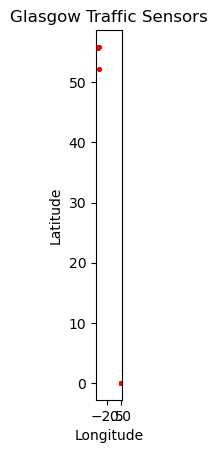

In [26]:
ax = gdf.plot(marker='o', color='red', markersize=5)
ax.set_title('Glasgow Traffic Sensors')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [35]:
m = folium.Map(location=[55.8642, -4.2518], zoom_start=12)

In [39]:
for idx, row in gdf.iterrows():
    folium.Marker([row['latitude'], row['longitude']], popup=row['siteId']).add_to(m)

In [41]:
m.save('glasgow_traffic_sensors_map.html')